# Data Vortex A'26 — Round 3
## Public Reaction to Changes in the Recommendation Algorithm

**Team:** hy4366  \n**Source:** Hacker News public Algolia archive API  \n**Important limitation:** This is a historical public archive sample collected through the Hacker News Algolia archive API; it is not a continuous live stream.

In [1]:
from pathlib import Path
import json, sys, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd().resolve(); ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT/'src'))
metadata = json.loads((ROOT/'data/raw/collection_metadata.json').read_text(encoding='utf-8'))
print('Collection (UTC):', metadata['collection_start_timestamp'], 'to', metadata['collection_end_timestamp'])
print('Raw archive source:', metadata['source'])
print('Queries:', '; '.join(metadata['query_terms']))

Collection (UTC): 2026-09-21T19:44:34.808161+00:00 to 2026-09-21T19:44:49.802497+00:00
Raw archive source: Hacker News public Algolia archive API
Queries: Twitter recommendation algorithm; YouTube recommendation algorithm; Instagram algorithm change; feed algorithm; recommendation algorithm; recommendation ranking; Facebook news feed algorithm; algorithmic feed


## 1. Dataset loading and data-quality audit
The correction pass reuses the saved raw archive export; it does not collect new data.

In [2]:
raw = pd.read_csv(ROOT/'data/raw/hn_recommendation_algorithm_reactions_raw.csv')
df = pd.read_csv(ROOT/'data/processed/round3_recommendation_algorithm_reactions.csv')
raw['timestamp'] = pd.to_datetime(raw['timestamp'], utc=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
audit = pd.read_csv(ROOT/'results/relevance_filter_audit.csv')
print('Raw records:', len(raw), '| final retained:', len(df))
print('Observation window:', df.timestamp.min(), 'to', df.timestamp.max())
display(audit)
display(pd.DataFrame({'missing_values': df.isna().sum(), 'dtype': df.dtypes.astype(str)}))
print('Exact duplicate rows:', df.duplicated().sum(), '| duplicate cleaned text:', df.cleaned_text.duplicated().sum(), '| empty text:', df.text.fillna('').str.strip().eq('').sum())
display(df[['source','source_type','query_term']].value_counts().to_frame('records').head(15))

Raw records: 389 | final retained: 204
Observation window: 2011-02-02 06:34:14+00:00 to 2026-09-21 18:49:57+00:00


,initial_screened_records,excluded_empty_or_short_text,excluded_not_specific_to_change_or_reaction,excluded_duplicate_cleaned_text,final_retained_records
0,389,0,182,5,204


,missing_values,dtype
id,0,str
source,0,str
source_type,0,str
timestamp,0,"datetime64[us, UTC]"
date,0,str
text,0,str
title,0,str
url,0,str
author_or_author_id_if_appropriate,0,str
engagement_score,152,float64


Exact duplicate rows: 0 | duplicate cleaned text: 0 | empty text: 0


records
source      source_type    query_term                               
Hacker News public_comment Twitter recommendation algorithm       35
                           YouTube recommendation algorithm       33
            public_story   feed algorithm                         26
            public_comment Instagram algorithm change             25
                           recommendation ranking                 24
                           Facebook news feed algorithm           20
                           algorithmic feed                       15
            public_story   Twitter recommendation algorithm       11
                           YouTube recommendation algorithm        7
                           recommendation algorithm                6
                           recommendation ranking                  1
                           Facebook news feed algorithm            1

## 2. Preprocessing and Round 2 NLP model
Raw text is preserved. The documented stricter relevance screen requires recommendation/feed context plus a concrete change, reaction, quality, or user-control signal. The exact preserved Round 2 TF-IDF + Logistic Regression pipeline is loaded directly.

Model type: <class 'sklearn.pipeline.Pipeline'>
Classes: ['Negative' 'Neutral' 'Positive']
Predictions reproduce saved CSV: True


,count,percent
predicted_sentiment,,
Positive,34,16.67
Negative,132,64.71
Neutral,38,18.63


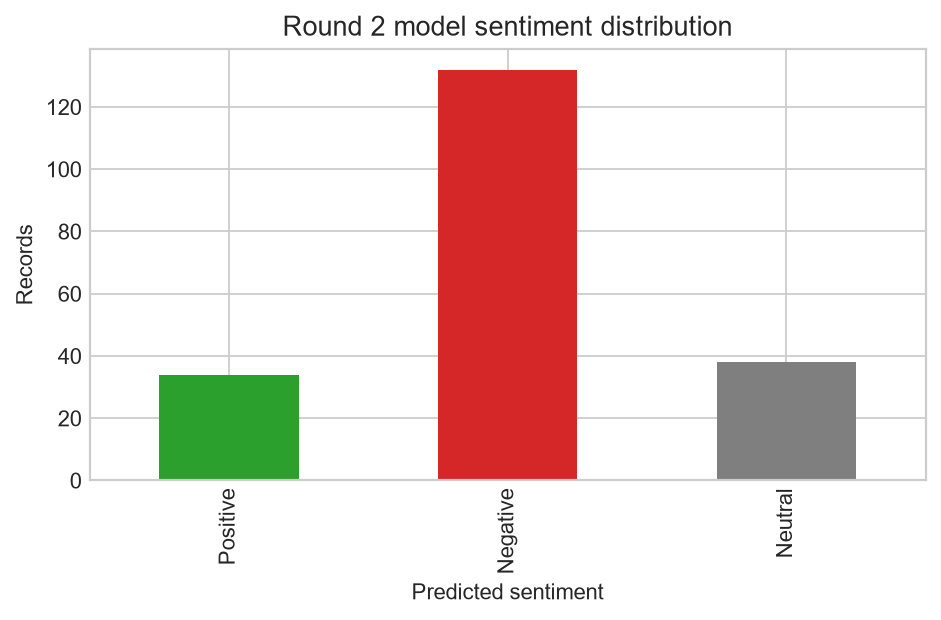

In [3]:
import joblib
model = joblib.load(ROOT.parent/'Round-2/models/sentiment_label_pipeline.pkl')
print('Model type:', type(model))
print('Classes:', model.classes_)
check = model.predict(df.cleaned_text)
print('Predictions reproduce saved CSV:', bool((check == df.predicted_sentiment).all()))
counts = df.predicted_sentiment.value_counts().reindex(['Positive','Negative','Neutral'], fill_value=0)
display(pd.DataFrame({'count':counts, 'percent':(counts/len(df)*100).round(2)}))
Image(filename=str(ROOT/'figures/sentiment_distribution.png'))

## 3. Sentiment over time and descriptive candidate shifts
Monthly index = `(Positive − Negative) / (Positive + Negative + Neutral)`. Candidate shifts require at least three records in each adjacent observed month. Because monthly n is small, these are descriptive candidates, not statistically significant behavioural shifts.

,month,Positive,Negative,Neutral,record_count,sentiment_index
74,2024-11,2,3,0,5,-0.200000
75,2024-12,0,3,0,3,-1.000000
76,2025-01,0,2,1,3,-0.666667
77,2025-02,0,3,0,3,-1.000000
78,2025-03,0,1,0,1,-1.000000
79,2025-04,0,3,0,3,-1.000000
80,2025-05,0,1,0,1,-1.000000
81,2025-07,1,0,0,1,1.000000
82,2025-08,0,1,0,1,-1.000000
83,2025-09,2,3,0,5,-0.200000


,shift_id,start_time,end_time,before_sentiment,after_sentiment,magnitude,record_count_before,record_count_after
0,SS1,2025-09,2025-10,-0.2,-1.0,-0.8,5,3
1,SS2,2024-10,2024-11,-1.0,-0.2,0.8,4,5


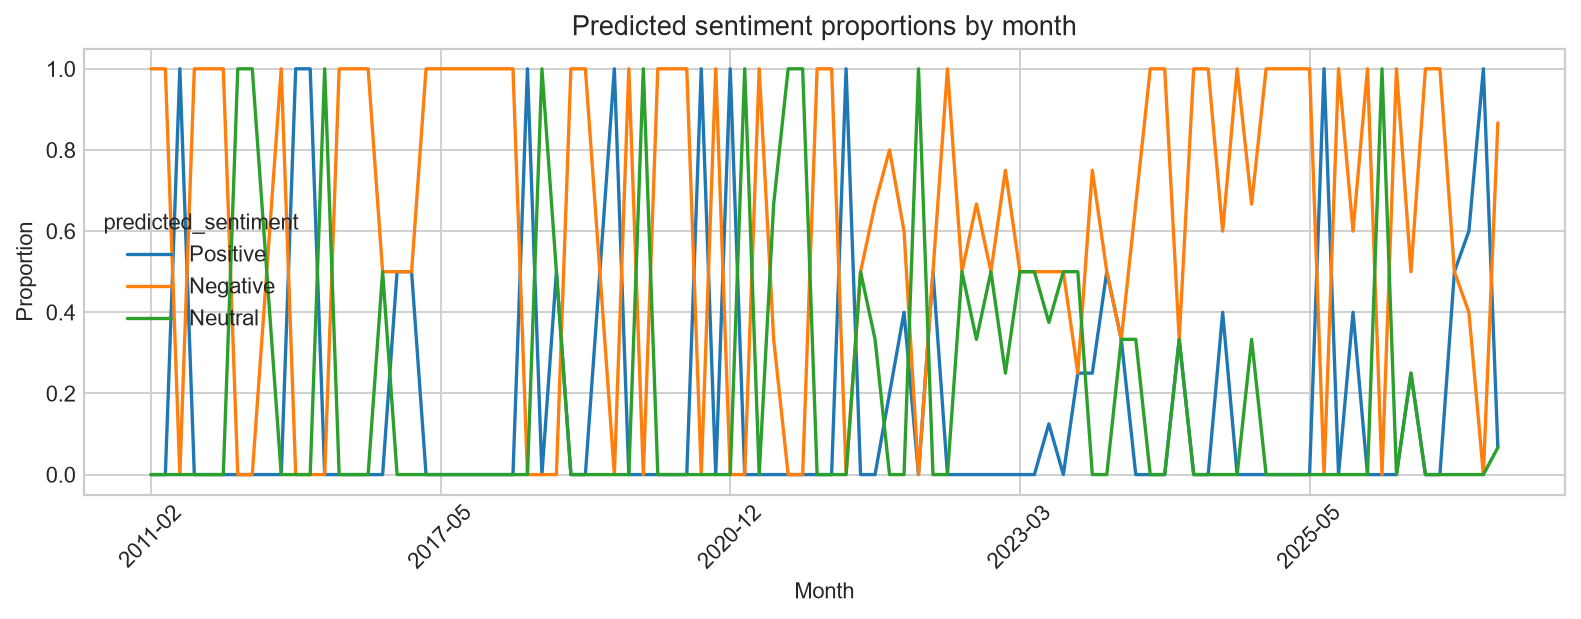

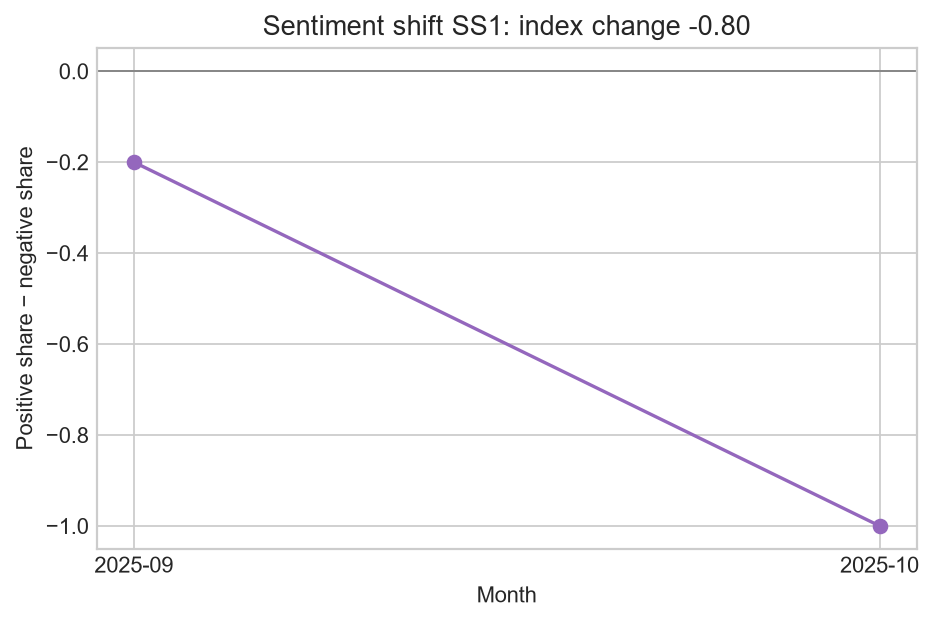

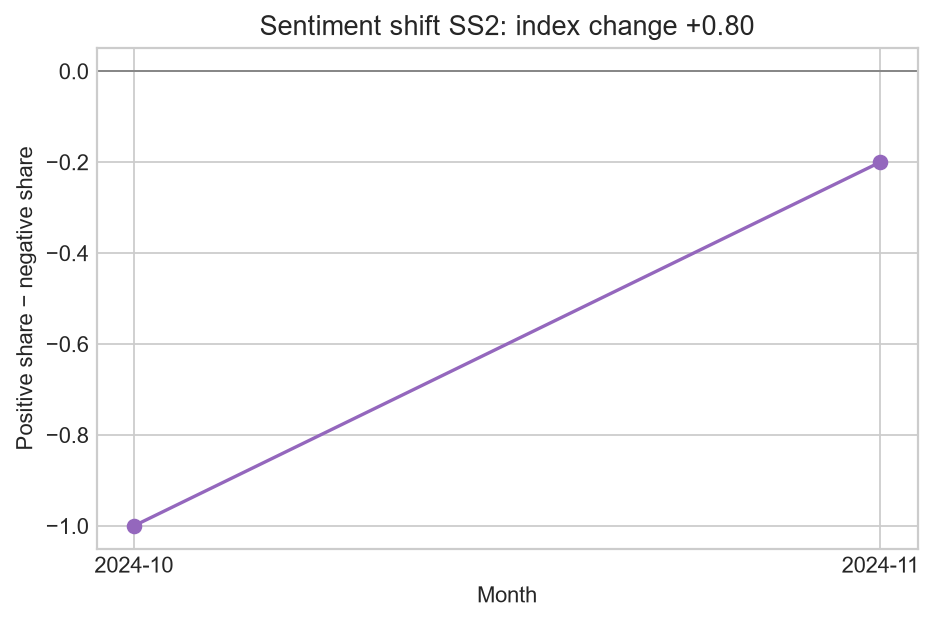

In [4]:
monthly = pd.read_csv(ROOT/'results/sentiment_by_month.csv')
shifts = pd.read_csv(ROOT/'results/detected_sentiment_shifts.csv')
display(monthly[['month','Positive','Negative','Neutral','record_count','sentiment_index']].tail(20))
display(shifts[['shift_id','start_time','end_time','before_sentiment','after_sentiment','magnitude','record_count_before','record_count_after']])
for f in ['sentiment_over_time.png','sentiment_shift_1.png','sentiment_shift_2.png']:
    display(Image(filename=str(ROOT/'figures'/f)))

## 4. Activity and available Hacker News score
“Engagement” means available Hacker News story score, not a universal social-media engagement measure. The reference baseline is the median monthly total among observed scored months; missing comment scores are not converted to zero.

,month,activity_count,score_record_count,total_engagement,average_engagement,median_engagement,maximum_engagement,engagement_baseline_median,engagement_ratio
74,2024-11,5,0,0.0,NaN,NaN,NaN,6.0,0.000000
75,2024-12,3,0,0.0,NaN,NaN,NaN,6.0,0.000000
76,2025-01,3,0,0.0,NaN,NaN,NaN,6.0,0.000000
77,2025-02,3,0,0.0,NaN,NaN,NaN,6.0,0.000000
78,2025-03,1,0,0.0,NaN,NaN,NaN,6.0,0.000000
79,2025-04,3,0,0.0,NaN,NaN,NaN,6.0,0.000000
80,2025-05,1,0,0.0,NaN,NaN,NaN,6.0,0.000000
81,2025-07,1,0,0.0,NaN,NaN,NaN,6.0,0.000000
82,2025-08,1,0,0.0,NaN,NaN,NaN,6.0,0.000000
83,2025-09,5,3,265.0,88.333333,14.0,249.0,6.0,44.166667


,spike_id,timestamp_time_window,activity_count,engagement_value,baseline,spike_ratio_or_zscore_or_percentile,evidence_records
0,ES1,2023-03,6,1704.0,6.0,284.000000,https://news.ycombinator.com/item?id=35391433 ...
1,ES2,2026-02,4,338.0,6.0,56.333333,https://news.ycombinator.com/item?id=47020218 ...
2,ES3,2025-09,5,265.0,6.0,44.166667,https://news.ycombinator.com/item?id=45183039 ...


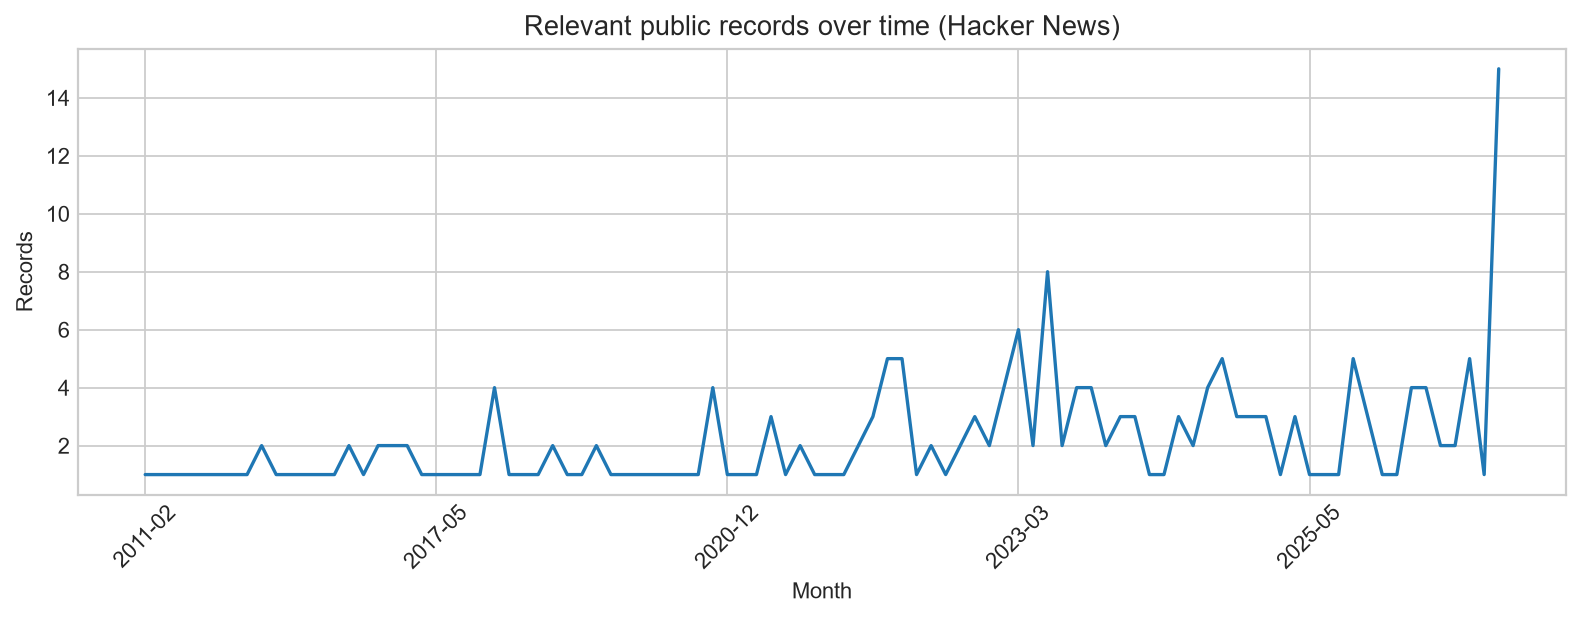

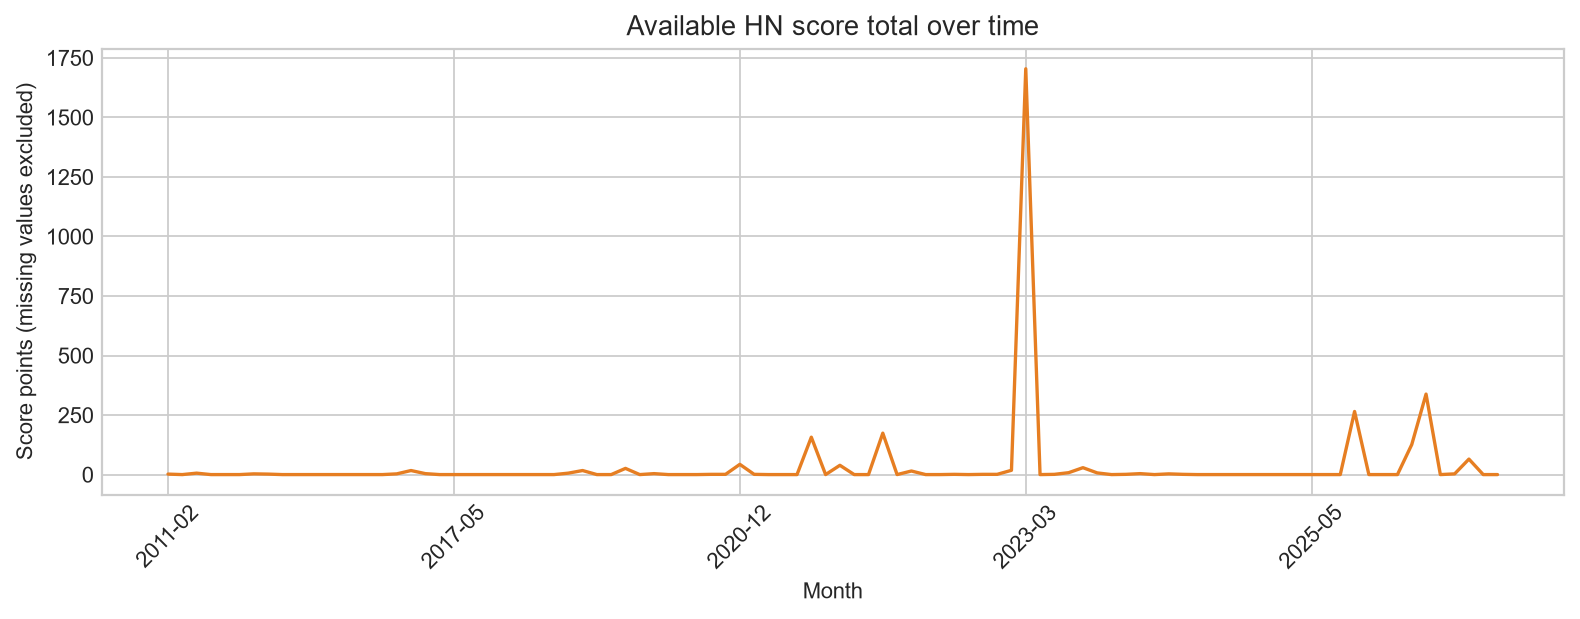

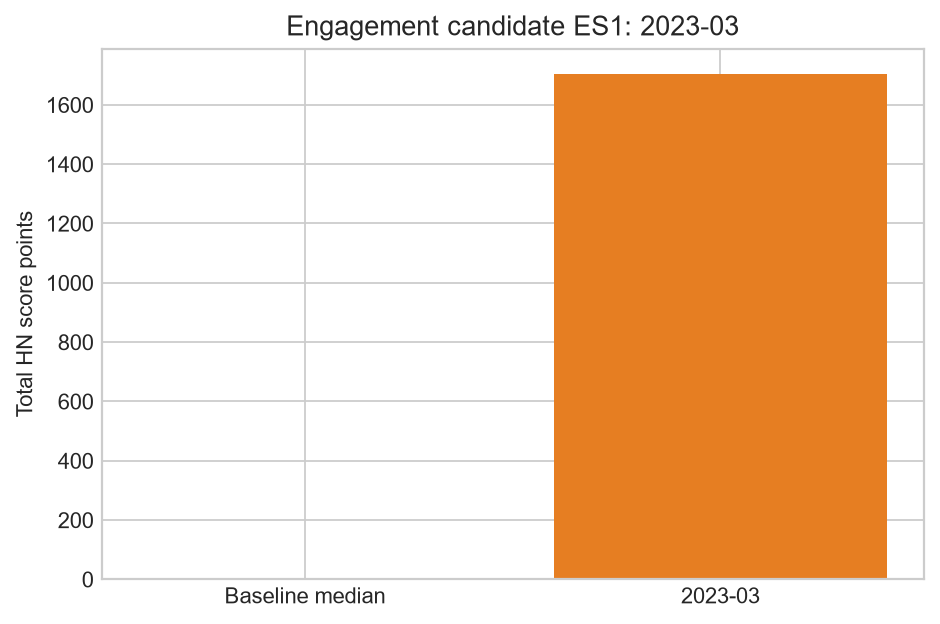

In [5]:
activity = pd.read_csv(ROOT/'results/activity_results.csv')
spikes = pd.read_csv(ROOT/'results/detected_engagement_spikes.csv')
display(activity.tail(20))
display(spikes[['spike_id','timestamp_time_window','activity_count','engagement_value','baseline','spike_ratio_or_zscore_or_percentile','evidence_records']])
for f in ['data_collection_overview.png','engagement_over_time.png','engagement_spike.png']:
    display(Image(filename=str(ROOT/'figures'/f)))

## 5. Data-derived TF-IDF terms and entities
TF-IDF uses English and documented custom stopwords. Terms are data-derived keywords, not semantic topic-model labels. Entities use a documented platform/product gazetteer; bare `X` is excluded unless explicit platform context is present.

,term,tfidf_total
0,youtube,35.252315
1,twitter,26.910664
2,facebook,26.416824
3,feed,25.485057
4,algorithmic,17.977656
5,tiktok,12.112217
6,instagram,11.225886
7,feeds,11.112986
8,better,10.330280
9,source,10.252936


,entity,frequency,method
0,YouTube,70,"case-insensitive gazetteer, documented platfor..."
1,Twitter,66,"case-insensitive gazetteer, documented platfor..."
2,Facebook,59,"case-insensitive gazetteer, documented platfor..."
3,Instagram,32,"case-insensitive gazetteer, documented platfor..."
4,TikTok,26,"case-insensitive gazetteer, documented platfor..."
5,Google,19,"case-insensitive gazetteer, documented platfor..."
6,Reddit,10,"case-insensitive gazetteer, documented platfor..."
7,GitHub,7,"case-insensitive gazetteer, documented platfor..."
8,Meta,6,"case-insensitive gazetteer, documented platfor..."
9,Netflix,3,"case-insensitive gazetteer, documented platfor..."


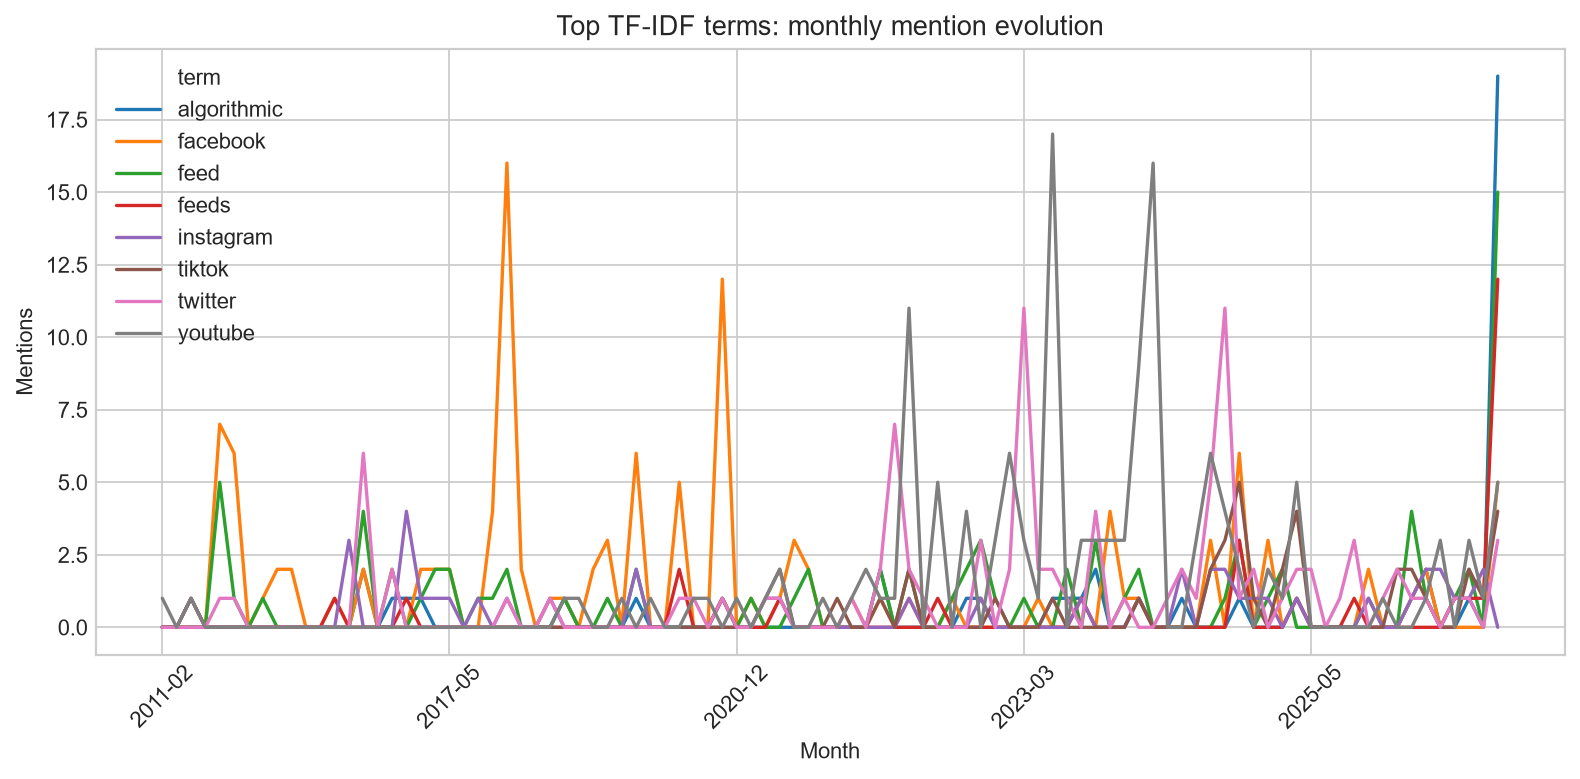

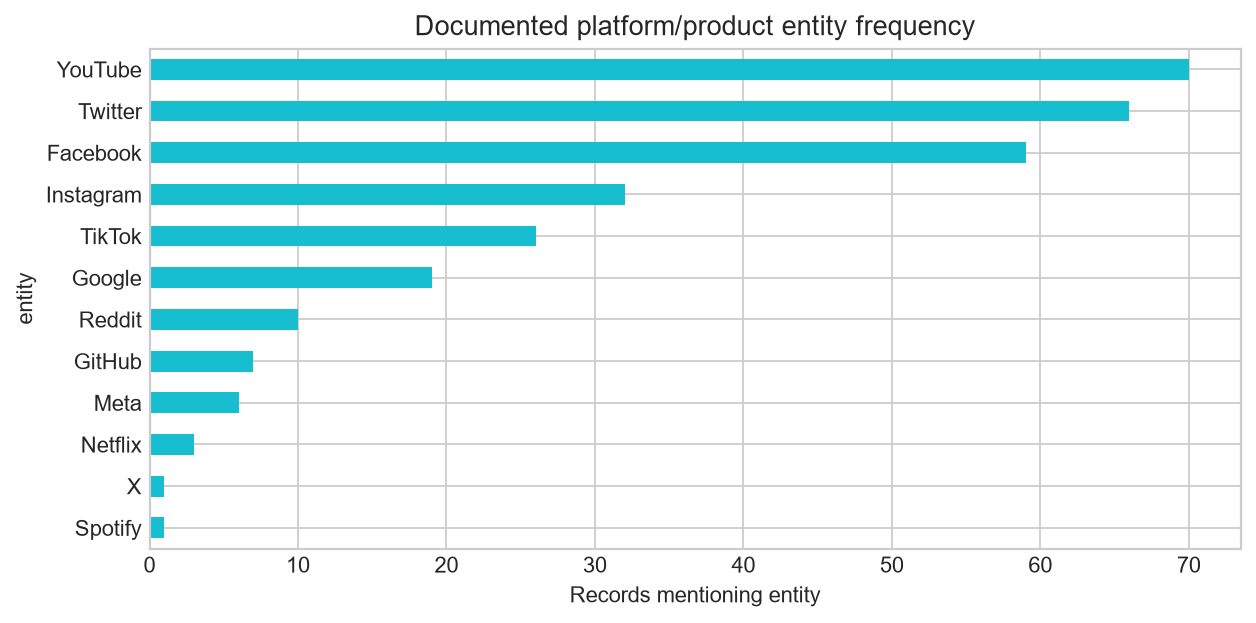

In [6]:
topics = pd.read_csv(ROOT/'results/topic_results.csv')
entities = pd.read_csv(ROOT/'results/entity_results.csv')
display(topics.head(15))
display(entities)
for f in ['topic_evolution.png','entity_frequency.png']:
    display(Image(filename=str(ROOT/'figures'/f)))

## 6. Trigger evidence, findings, limitations, and conclusion
Evidence records establish temporal coincidence only. No causal claim is made. The historical archive window, technical-community source, sparse monthly windows, and score-missing comments limit inference.

,event_id,article_or_post_title,publication_timestamp,url,reason_relevant
0,ES1,Twitter's Recommendation Algorithm,2023-03-31 18:42:16+00:00,https://news.ycombinator.com/item?id=35391433,Collected contemporaneous evidence record; sup...
1,ES1,"Twitter reveals some of its source code, inclu...",2023-03-31 22:02:37+00:00,https://news.ycombinator.com/item?id=35394275,Collected contemporaneous evidence record; sup...
2,ES1,Twitter will open source all code used to reco...,2023-03-17 22:38:00+00:00,https://news.ycombinator.com/item?id=35203828,Collected contemporaneous evidence record; sup...
3,SS1,NL Judge: Meta must respect user's choice of r...,2025-10-02 18:28:07+00:00,https://news.ycombinator.com/item?id=45453468,Collected contemporaneous evidence record; sup...
4,SS1,Study finds growing social circles may fuel po...,2025-10-28 08:41:36+00:00,https://news.ycombinator.com/item?id=45730455,Collected contemporaneous evidence record; sup...
5,SS1,Grokipedia Review,2025-10-29 04:16:25+00:00,https://news.ycombinator.com/item?id=45742557,Collected contemporaneous evidence record; sup...
6,SS2,Trudeau government bans TikTok from operating ...,2024-11-08 17:42:11+00:00,https://news.ycombinator.com/item?id=42088781,Collected contemporaneous evidence record; sup...
7,SS2,"Maybe Bluesky has ""won""",2024-11-15 20:18:42+00:00,https://news.ycombinator.com/item?id=42150481,Collected contemporaneous evidence record; sup...
8,SS2,Ask HN: Where to advertise my SaaS other than ...,2024-11-26 11:51:02+00:00,https://news.ycombinator.com/item?id=42244890,Collected contemporaneous evidence record; sup...


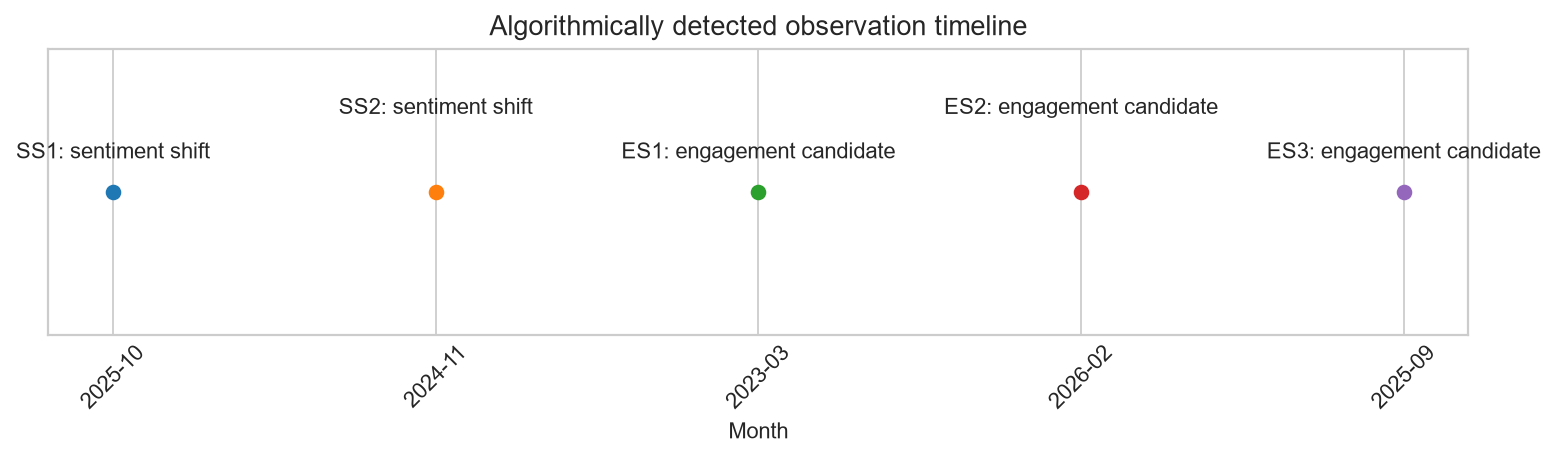

Findings:
- Final retained records: 204
- Sentiment counts: {'Positive': 34, 'Negative': 132, 'Neutral': 38}
- Descriptive candidate shifts: [{'shift_id': 'SS1', 'start_time': '2025-09', 'end_time': '2025-10', 'magnitude': -0.8}, {'shift_id': 'SS2', 'start_time': '2024-10', 'end_time': '2024-11', 'magnitude': 0.8}]
- Highest available-score engagement candidate: {'timestamp_time_window': '2023-03', 'engagement_value': 1704.0, 'baseline': 6.0}
Conclusion: Findings are reproducible, source-bound descriptive observations; they do not prove causal public reaction.


In [7]:
evidence = pd.read_csv(ROOT/'results/trigger_evidence.csv')
display(evidence[['event_id','article_or_post_title','publication_timestamp','url','reason_relevant']])
display(Image(filename=str(ROOT/'figures/trigger_timeline.png')))
print('Findings:')
print('- Final retained records:', len(df))
print('- Sentiment counts:', counts.to_dict())
print('- Descriptive candidate shifts:', shifts[['shift_id','start_time','end_time','magnitude']].to_dict('records'))
print('- Highest available-score engagement candidate:', spikes.iloc[0][['timestamp_time_window','engagement_value','baseline']].to_dict())
print('Conclusion: Findings are reproducible, source-bound descriptive observations; they do not prove causal public reaction.')